In [4]:
import numpy as np

import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from datetime import datetime
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_model import  ARIMA,ARIMAResults
from statsmodels.tsa.ar_model import AR,ARResults
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [5]:
df= pd.read_csv("FremontHourly.csv",index_col='Date',parse_dates=['Date'])
df.head()

,Fremont Bridge NB,Fremont Bridge SB
Date,,
2012-10-02 00:00:00,0.0,0.0
2012-10-02 01:00:00,0.0,0.0
2012-10-02 02:00:00,0.0,0.0
2012-10-02 03:00:00,0.0,0.0
2012-10-02 04:00:00,0.0,0.0


In [6]:
df['total'] = df['Fremont Bridge NB']+df['Fremont Bridge SB']
df.tail()
df.fillna(method="ffill")

,Fremont Bridge NB,Fremont Bridge SB,total
Date,,,
2012-10-02 00:00:00,0.0,0.0,0.0
2012-10-02 01:00:00,0.0,0.0,0.0
2012-10-02 02:00:00,0.0,0.0,0.0
2012-10-02 03:00:00,0.0,0.0,0.0
2012-10-02 04:00:00,0.0,0.0,0.0
...,...,...,...
2014-05-31 19:00:00,69.0,65.0,134.0
2014-05-31 20:00:00,43.0,61.0,104.0
2014-05-31 21:00:00,27.0,27.0,54.0


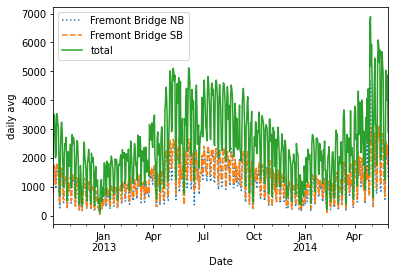

In [7]:
daily = df.resample('D').sum()
daily.plot(style=[':', '--', '-'])
plt.ylabel('daily avg')
plt.show();

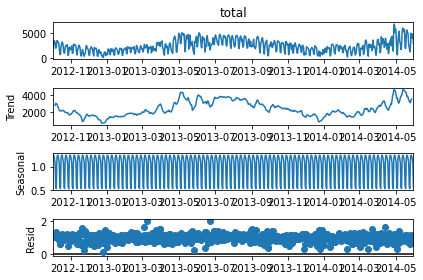

In [8]:
daily.isnull().sum()
mul = seasonal_decompose(daily['total'],model='multiplicative')
mul.plot();

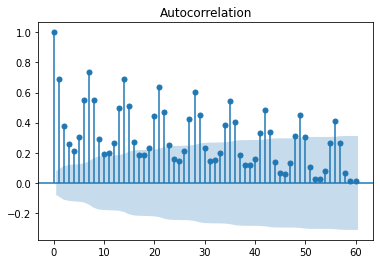

In [9]:
from statsmodels.tsa.stattools import acf,pacf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plot_acf(daily.total.tolist(),lags=60)

plt.show()

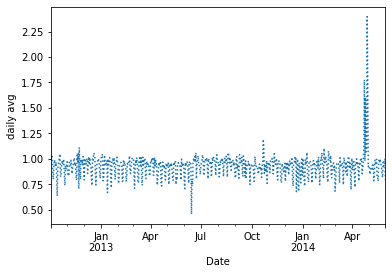

In [10]:
daily['ratio'] = daily['Fremont Bridge NB']/daily['Fremont Bridge SB']
daily['ratio'].plot(style=[':', '--', '-'])
plt.ylabel('daily avg')
plt.show();

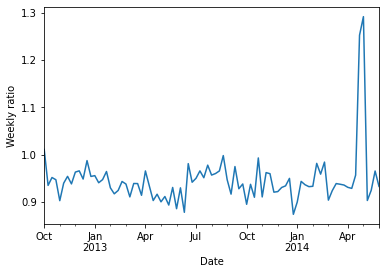

In [11]:
weekly = daily.resample('W').sum()
weekly['ratio']=weekly['Fremont Bridge NB']/weekly['Fremont Bridge SB']
weekly['ratio'].plot(style=['-'])
plt.ylabel('Weekly ratio')
plt.show();

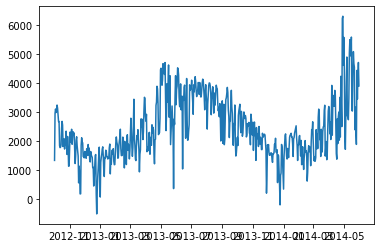

In [12]:
res_mul = seasonal_decompose(daily['total'], model='additive') # deseasonalize
deseasonal = daily.total.values-res_mul.seasonal

plt.plot(deseasonal)

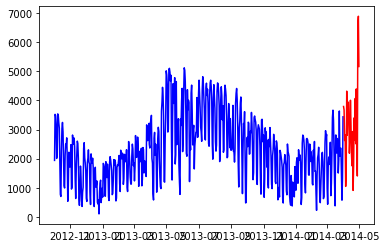

In [13]:
train = daily['2012-10-02':'2014-03-31'].copy()
test = daily['2014-04-01':'2014-04-30'].copy()
plt.plot(train['total'],color='b')
plt.plot(test['total'],color='r')
plt.show()

In [21]:

arima_model =  auto_arima(train['total'],start_p=0, d=1, start_q=0, 
                          max_p=5, max_d=5, max_q=5, start_P=0, 
                          D=1, start_Q=0, max_P=5, max_D=5,
                          max_Q=5, m=7, seasonal=True, 
                          error_action='warn',trace = True,
                           supress_warnings=True,stepwise = False,random=True,
                          random_state=20,n_fits = 20 )

 ARIMA(1,1,0)(0,1,0)[7]             : AIC=8624.395, Time=0.03 sec
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=8650.572, Time=0.01 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=8452.517, Time=0.79 sec
 ARIMA(0,1,4)(0,1,1)[7]             : AIC=inf, Time=2.07 sec
 ARIMA(1,1,1)(3,1,0)[7]             : AIC=inf, Time=4.74 sec
 ARIMA(2,1,1)(1,1,0)[7]             : AIC=inf, Time=1.45 sec
 ARIMA(4,1,0)(0,1,1)[7]             : AIC=inf, Time=1.48 sec
 ARIMA(0,1,2)(0,1,2)[7]             : AIC=inf, Time=2.65 sec
 ARIMA(2,1,0)(1,1,2)[7]             : AIC=inf, Time=3.74 sec
 ARIMA(1,1,0)(3,1,1)[7]             : AIC=inf, Time=6.55 sec
 ARIMA(0,1,3)(0,1,0)[7]             : AIC=inf, Time=0.41 sec
 ARIMA(0,1,2)(0,1,1)[7]             : AIC=inf, Time=1.11 sec
 ARIMA(0,1,0)(0,1,5)[7]             : AIC=inf, Time=11.70 sec
 ARIMA(4,1,0)(0,1,0)[7]             : AIC=8586.194, Time=0.11 sec
 ARIMA(0,1,0)(0,1,1)[7]             : AIC=inf, Time=0.36 sec
 ARIMA(0,1,0)(0,1,2)[7]             : AIC=inf, Time=1.37 sec
 AR

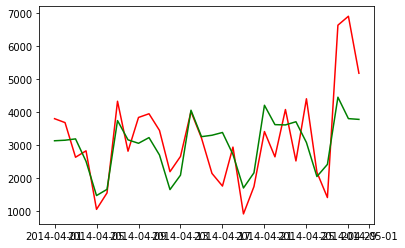

In [22]:

prediction = pd.DataFrame(arima_model.predict(n_periods = 30),index=test.index)
prediction.columns = ['predicted_riders']
plt.plot(test['total'],color='r')
plt.plot(prediction['predicted_riders'],color='g')
plt.show()

In [23]:
print(np.mean(np.abs((test['total'] - prediction['predicted_riders']) / test['total'])) * 100)

28.12119370985013
